In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
from scipy.interpolate import interp1d
from scipy import stats
import Functions_14CO as F
from InSitu14CO import Propagator

from tqdm import tqdm
from scipy.io import loadmat

import pandas as pd

import pyunfold as pu

from InSitu14CO import T

In [2]:
M = loadmat('matlab/MC_14CO_mod/flowpath_sample.mat')

In [3]:
np.shape(M['age'])

(1, 861)

Text(0, 0.5, 'Depth [m]')

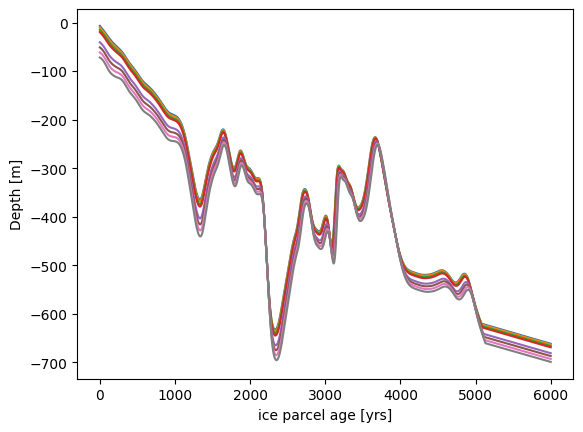

In [4]:
plt.plot(M['age'][0],M['h_age'][:,0].T)
plt.xlabel('ice parcel age [yrs]')
plt.ylabel('Depth [m]')

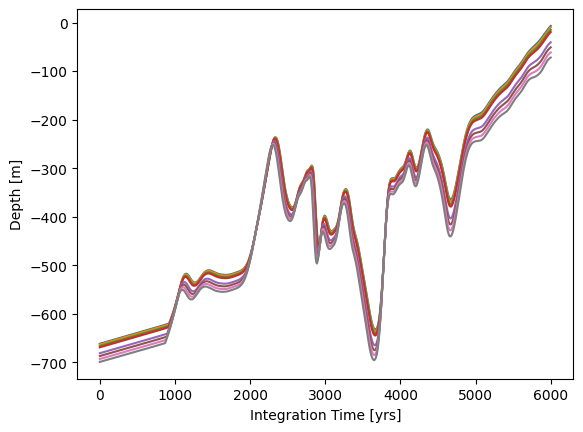

In [5]:
t = np.arange(M['age'][0,0],M['age'][0,-1],0.5)
depth = np.flip(interp1d(M['age'][0], M['h_age'][:,0],assume_sorted=True)(t).T, axis=0)
depth2 = np.interp(np.flip(t), M['age'][0], M['h_age'][0,0])
plt.plot(t,depth)
#plt.plot(t,depth2)
plt.xlabel('Integration Time [yrs]')
plt.ylabel('Depth [m]')
plt.show()

In [6]:
# This method sets the conditions for this study at Taylor Glacier by Dyonisius et al. (https://tc.copernicus.org/articles/17/843/2023/)
Prop = Propagator(pressure=9.248658001389917e+04, # (Pa) pressure used in Taylor Glacier analysis "from LSD ERA reanalysis"
                  elev=526, # (m) elevation listed in Figure 1 caption of Taylor Glacier study (need to confirm)
                  rho_ice=0.92) # (g/cm^3) density used in Taylor Glacier analysis
h_bins = np.arange(0.,1001.,1.)
Prop.set_mass_depth(z_bins=h_bins/0.92, h_bins=h_bins, z_min=0., z_deep=h_bins[-1]/0.92)
# sample mid depths = [6.85, 10., 15, 19.5, 40.5, 51, 61.5, 72.]
density_model = ('MSIS00', ('SouthPole', 'January'))
tag = 'TaylorGlacier'

In [7]:
# load production rates
df_Pfast = pd.read_csv('Production Rates/P_fast_TaylorGlacier_526m.csv')
df_Pneg = pd.read_csv('Production Rates/P_neg_TaylorGlacier_526m.csv')
P_14C = np.swapaxes([df_Pfast.T, df_Pneg.T], 0, 1)
model_names = list(df_Pfast.columns)

In [8]:
# calculate 14CO concentrations (without f-factors)
Prop.Phi['prod']=P_14C
C_flow = F.Taylor_flow(Prop, 'best')

100%|██████████████████████████████████████████████████████████████████████████| 12000/12000 [00:00<00:00, 25872.25it/s]


In [9]:
np.shape(C_flow)

(1, 15, 2, 8)

In [10]:
# calculate 14CO concentrations (without f-factors)
Prop.Phi['prod']=P_14C
C_response, C_init = F.Taylor_flow_response(Prop, 'best')

In [11]:
np.shape(C_response)

(1, 15, 2, 12000, 8)

In [12]:
np.shape(C_init)

(1, 15, 2, 8)

In [13]:
TG_data = loadmat('matlab/MC_14CO_mod/TG_data_14CO.mat')

In [14]:
C_exp = TG_data['CO_molec'][3:,0]
C_err = TG_data['CO_molec_err'][3:,0]/2.
z_samp = TG_data['sample_depth_CO'][3:,0]

In [15]:
P_neutron = loadmat('matlab/MC_14CO_mod/P_neutron.mat')

In [16]:
P_n0 = P_neutron['Lal_P_n'][0]
Z_n = P_neutron['Z_neutron'][0]
P_n = np.interp(Prop.z_bins, Z_n, P_n0)

In [17]:
Prop.Phi['prod']=P_n.reshape((1,1,-1))
z = np.copy(Prop.z)
Prop.z = Prop.z_bins
C_n = F.Taylor_flow(Prop, 'best')
Prop.z = z

100%|██████████████████████████████████████████████████████████████████████████| 12000/12000 [00:00<00:00, 30762.34it/s]


In [18]:
# SET TIME-DEPENDENT FLUX MODEL

flowpath = loadmat('matlab/MC_14CO_mod/flowpath_sample.mat')

age = flowpath['age'][0]
# age : ice parcel ages [years]
#axis0 - ice parcel age

dt = 0.5
t_bins = np.arange(age[0], age[-1]+dt, dt) # time integration steps
t = (t_bins[:-1]+t_bins[1:])/2

t_bins = t_bins-t_bins[-1] # time in years, with 0=present
t = t-t_bins[-1]
t_scale = t/-t_bins[0] # time scaled from -1 to 0, with 0=present
t_bins_scale = (t_bins/-t_bins[0]).reshape((1,-1))
dt_bins_scale = np.diff(t_bins_scale,axis=-1)

N_poly = 5

f_poly = np.array([t_scale**i for i in range(N_poly)])

N_step = 100

#t_step = np.reshape(np.linspace(-1., 0., N_step+1), (-1,1))
#f_step = ((t_step[1:]-t_bins_scale[:,:-1]).clip(0,dt_bins_scale) - (t_step[:-1]-t_bins_scale[:,:-1]).clip(0,dt_bins_scale))/dt_bins_scale
t_step = np.reshape(np.arange(-1.,2./(N_step-1),1./(N_step-1)), (-1,1))
f_step = ((t_step[1:]-t_bins_scale[:,:-1]).clip(0,1./(N_step-1)) - (t_step[:-1]-t_bins_scale[:,:-1]).clip(0,1./(N_step-1)))*(N_step-1)

N_interp = 6

t_step = np.reshape(np.arange(-1.,2./(N_interp-1),1./(N_interp-1)), (-1,1))
f_interp = ((t_step[1:]-t_bins_scale[:,:-1]).clip(0,1./(N_interp-1)) - (t_step[:-1]-t_bins_scale[:,:-1]).clip(0,1./(N_interp-1)))*(N_interp-1)

In [19]:
C_poly = np.swapaxes(f_poly @ C_response, -3,-2)
C_step = np.swapaxes(f_step @ C_response, -3,-2)
C_interp = np.swapaxes(f_interp @ C_response, -3,-2)

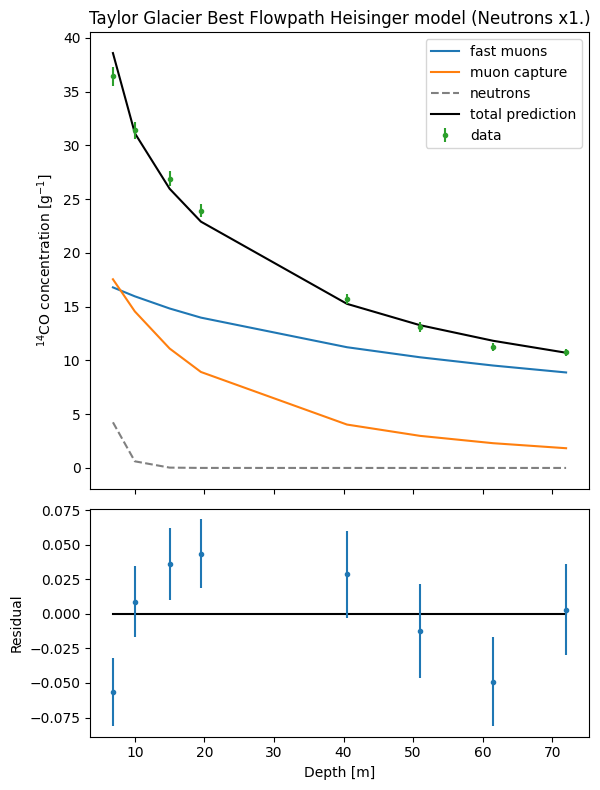

flowpath #0
Heisinger
f = [0.08839759 0.05859419]
chi2 = 14.055742241178747
chi2_nu = 2.3426237068631246
logL = -3.18170337866287
p = 0.029019652526573094
sig = 2.183219457579373


In [20]:
i = 0 # flowpath # 0 = "best" flowpath
j = -1 # production model

f_n = 1. #neutron production scaling factor

# calculate best-fit f-factors with the pseudoinverse
C = C_flow[i,j].T
Sigma = np.diag(C_err**2)
Sigma_inv = np.linalg.inv(Sigma)
f = np.linalg.inv(C.T @ Sigma_inv @ C) @ C.T @ Sigma_inv @ (C_exp-C_n[i,0,0]*f_n)

#f = np.array([0.085,0.066])

fig, (ax1,ax2) = plt.subplots(2,1, figsize=(6,8), tight_layout=True, sharex=True, height_ratios=[2,1])

ax1.plot(z_samp, C[:,0]*f[0], label='fast muons')
#ax2.plot(z_samp, C[:,0]*f[0] / C_exp -1, label='fast muons')

ax1.plot(z_samp, C[:,1]*f[1], label='muon capture')
#ax2.plot(z_samp, C[:,1]*f[1] / C_exp -1, label='muon capture')

if f_n>0:
    ax1.plot(z_samp, C_n[i,0,0]*f_n, c='gray', ls='--', label='neutrons')
    #ax2.plot(z_samp, C_n[i,0,0]*f_n / C_exp -1, c='gray', ls='--', label='neutrons')

ax1.plot(z_samp, C@f + C_n[i,0,0]*f_n, c='k', label='total prediction')
ax2.plot(z_samp, (C@f + C_n[i,0,0]*f_n) / (C@f + C_n[i,0,0]*f_n) -1, c='k', label='total prediction')

ax1.errorbar(z_samp, C_exp, yerr=C_err, fmt='.', label='data')
ax2.errorbar(z_samp, C_exp / (C@f + C_n[i,0,0]*f_n) -1, yerr=C_err / C_exp, fmt='.', label='data')

ax1.set(#xlabel='Depth [m]',
           #xscale='log',
           ylabel=r'$^{14}$CO concentration [g$^{-1}$]',
           #yscale='log',
      )
ax2.set(xlabel='Depth [m]',
           #xscale='log',
           ylabel='Residual',
           #yscale='log',
      )
ax1.title.set_text('Taylor Glacier Best Flowpath Heisinger model (Neutrons x1.)')
ax1.legend()
#plt.title('Taylor Glacier Re-Analysis')
plt.show()

print('flowpath #{}'.format(i))
print(model_names[j])
print('f = {}'.format(f))

chi2 = (C@f-C_exp+C_n[i,0,0]*f_n).T@Sigma_inv@(C@f-C_exp+C_n[i,0,0]*f_n)
print('chi2 = {}'.format(chi2))
print('chi2_nu = {}'.format(chi2/(len(C_exp)-len(f))))

logL = -chi2/2  - np.log(2*np.pi*np.linalg.det(Sigma))/2
print('logL = {}'.format(logL))

p = stats.chi2.sf(chi2, len(C_exp)-len(f))
print('p = {}'.format(p))

sig = stats.norm.isf(p/2.)
print('sig = {}'.format(sig))

In [33]:
np.shape(C)

(8, 2)

In [30]:
f_prime = f + f_vec[:,0]*np.sqrt(f_var[0])*0.

chi2 = (C@f_prime-C_exp+C_n[i,0,0]*f_n).T@Sigma_inv@(C@f_prime-C_exp+C_n[i,0,0]*f_n)
print('chi2 = {}'.format(chi2))
print('chi2_nu = {}'.format(chi2/(len(C_exp)-len(f))))

logL = -chi2/2  - np.log(2*np.pi*np.linalg.det(Sigma))/2
print('logL = {}'.format(logL))

p = stats.chi2.sf(chi2, len(C_exp)-len(f))
print('p = {}'.format(p))

sig = stats.norm.isf(p/2.)
print('sig = {}'.format(sig))

chi2 = 14.055742241178747
chi2_nu = 2.3426237068631246
logL = -3.18170337866287
p = 0.029019652526573094
sig = 2.183219457579373


(51, 51)


/tmp/ipykernel_715/792987615.py:14: RuntimeWarning: invalid value encountered in sqrt
  sig1_dist = np.sqrt(stats.chi2.isf(stats.norm.sf(1.)*2., len(C_exp)-len(f)) - chi2_best)
/tmp/ipykernel_715/792987615.py:36: RuntimeWarning: invalid value encountered in sqrt
  sig_dist = np.sqrt(stats.chi2.isf(stats.norm.sf(sig)*2., len(C_exp)-len(f)) - chi2_best)


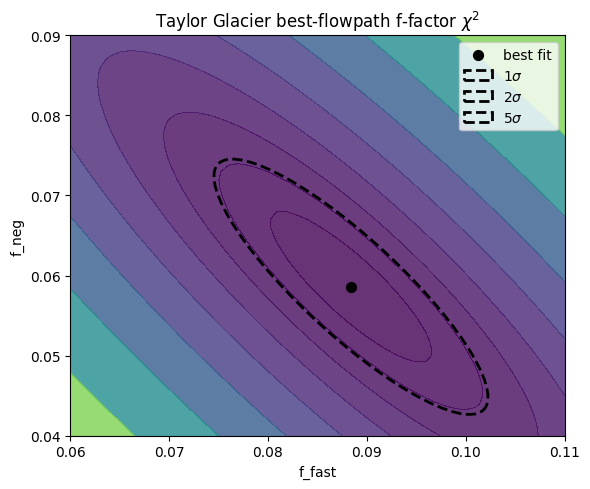

In [31]:
from matplotlib.patches import Ellipse

Sigma_f_inv = C.T @ Sigma_inv @ C
Sigma_f = np.linalg.inv(Sigma_f_inv)
f_var, f_vec = np.linalg.eig(Sigma_f)

# make eigenvectors point up (looks nice on plot)
f_vec[:,0] *= -1. if f_vec[1,0]<0. else 1.
f_vec[:,1] *= -1. if f_vec[1,1]<0. else 1.

fig, ax = plt.subplots(1,1, figsize=(6,5), tight_layout=True, sharex=True)

chi2_best = (C@f_prime-C_exp+C_n[i,0,0]*f_n).T@Sigma_inv@(C@f_prime-C_exp+C_n[i,0,0]*f_n)
sig1_dist = np.sqrt(stats.chi2.isf(stats.norm.sf(1.)*2., len(C_exp)-len(f)) - chi2_best)

w = 0.02
df = 0.001
#f0_grid = np.arange(f[0]-w, f[0]+w+df, df)
#f1_grid = np.arange(f[1]-w, f[1]+w+df, df)
f0_grid = np.arange(0.06, 0.11+df, df)
f1_grid = np.arange(0.04, 0.09+df, df)
f_grid = np.array(np.meshgrid(f0_grid, f1_grid)).swapaxes(0,1)
chi2_grid = np.sum( (C@f_grid-(C_exp-C_n[i,0,0]*f_n).reshape((1,-1,1))) * (Sigma_inv@(C@f_grid-(C_exp-C_n[i,0,0]*f_n).reshape((1,-1,1)))), axis=1)
print(np.shape(chi2_grid))

#levels = stats.chi2.isf(stats.norm.sf([0.,0.5,1.,1.5,2.,2.5,3.,4.,5.,6.,8.,10.,20.])*2., len(C_exp)-len(f))
#print(levels)

cf = ax.contourf(f0_grid, f1_grid, chi2_grid, alpha=0.8, levels=np.logspace(np.log10(np.min(chi2_grid)),np.log10(np.max(chi2_grid)),10))

plt.scatter(*f, s=50, c='k', label='best fit')
plt.arrow(f[0],f[1],f_vec[0,0]*np.sqrt(f_var[0])*sig1_dist,f_vec[1,0]*np.sqrt(f_var[0])*sig1_dist, width=0.01*w, length_includes_head=True, fc='k')
plt.arrow(f[0],f[1],f_vec[0,1]*np.sqrt(f_var[1])*sig1_dist,f_vec[1,1]*np.sqrt(f_var[1])*sig1_dist, width=0.01*w, length_includes_head=True, fc='k')

for sig in [1,2,5]:
    sig_dist = np.sqrt(stats.chi2.isf(stats.norm.sf(sig)*2., len(C_exp)-len(f)) - chi2_best)
    ellipse = Ellipse(xy=f, width=np.sqrt(f_var[0])*2*sig_dist, height=np.sqrt(f_var[1])*2*sig_dist, angle=np.arccos(f_vec[0,0])*180/np.pi, ec='k', fc='None', lw=2, ls='--', label=r'{}$\sigma$'.format(sig))
    ax.add_patch(ellipse)

ax.set(
    xlabel='f_fast',
    #xlim = (f[0]-0.01,f[0]+0.01),
    ylabel='f_neg',
    #ylim = (f[1]-0.01,f[1]+0.01)
)
ax.legend()
plt.title(r'Taylor Glacier best-flowpath f-factor $\chi^2$')
plt.show()

/tmp/ipykernel_715/1016494653.py:16: RuntimeWarning: invalid value encountered in sqrt
  sig1_dist = np.sqrt(stats.chi2.isf(stats.norm.sf(1.)*2., len(C_exp)-len(f)) - chi2_best)
/tmp/ipykernel_715/1016494653.py:40: RuntimeWarning: invalid value encountered in sqrt
  sig_dist = np.sqrt(stats.chi2.isf(stats.norm.sf(sig)*2., len(C_exp)-len(f)) - chi2_best)


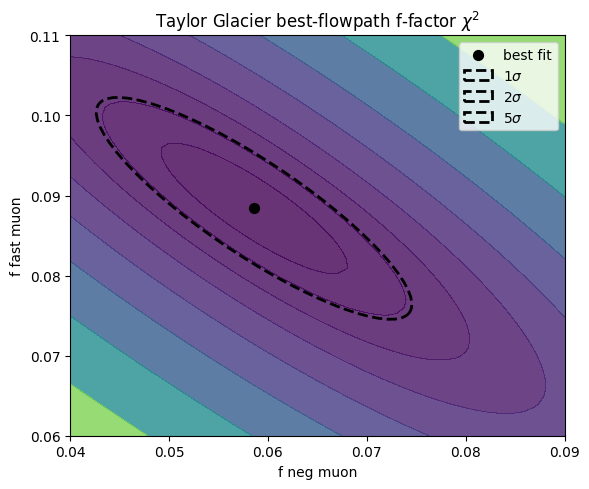

In [32]:
# Same as above, but with f_neg on the x-axis

from matplotlib.patches import Ellipse

Sigma_f_inv = C.T @ Sigma_inv @ C
Sigma_f = np.linalg.inv(Sigma_f_inv)
f_var, f_vec = np.linalg.eig(Sigma_f)

# make eigenvectors point up (looks nice on plot)
f_vec[:,0] *= -1. if f_vec[0,0]<0. else 1.
f_vec[:,1] *= -1. if f_vec[0,1]<0. else 1.

fig, ax = plt.subplots(1,1, figsize=(6,5), tight_layout=True, sharex=True)

chi2_best = (C@f_prime-C_exp+C_n[i,0,0]*f_n).T@Sigma_inv@(C@f_prime-C_exp+C_n[i,0,0]*f_n)
sig1_dist = np.sqrt(stats.chi2.isf(stats.norm.sf(1.)*2., len(C_exp)-len(f)) - chi2_best)

w = 0.02
df = 0.001
#f0_grid = np.arange(f[0]-w, f[0]+w+df, df)
#f1_grid = np.arange(f[1]-w, f[1]+w+df, df)
f0_grid = np.arange(0.06, 0.11+df, df)
f1_grid = np.arange(0.04, 0.09+df, df)
f_grid = np.flip(np.array(np.meshgrid(f1_grid, f0_grid)), axis=0).swapaxes(0,1)
chi2_grid = np.sum( (C@f_grid-(C_exp-C_n[i,0,0]*f_n).reshape((1,-1,1))) * (Sigma_inv@(C@f_grid-(C_exp-C_n[i,0,0]*f_n).reshape((1,-1,1)))), axis=1)

# chi2 without errors
#chi2_grid = np.sum( (C@f_grid-(C_exp-C_n[i,0,0]*f_n).reshape((1,-1,1)))**2 /(C@f_grid + (C_n[i,0,0]*f_n).reshape((1,-1,1))), axis=1)

#levels = stats.chi2.isf(stats.norm.sf([0.,0.5,1.,1.5,2.,2.5,3.,4.,5.,6.,8.,10.,20.])*2., len(C_exp)-len(f))
#print(levels)

cf = ax.contourf(f1_grid, f0_grid, chi2_grid, alpha=0.8, levels=np.logspace(np.log10(np.min(chi2_grid)),np.log10(np.max(chi2_grid)),10))

plt.scatter(*np.flip(f), s=50, c='k', label='best fit')
plt.arrow(f[1],f[0],f_vec[1,0]*np.sqrt(f_var[0])*sig1_dist,f_vec[0,0]*np.sqrt(f_var[0])*sig1_dist, width=0.01*w, length_includes_head=True, fc='k')
plt.arrow(f[1],f[0],f_vec[1,1]*np.sqrt(f_var[1])*sig1_dist,f_vec[0,1]*np.sqrt(f_var[1])*sig1_dist, width=0.01*w, length_includes_head=True, fc='k')

for sig in [1,2,5]:
    sig_dist = np.sqrt(stats.chi2.isf(stats.norm.sf(sig)*2., len(C_exp)-len(f)) - chi2_best)
    ellipse = Ellipse(xy=np.flip(f), width=np.sqrt(f_var[0])*2*sig_dist, height=np.sqrt(f_var[1])*2*sig_dist, angle=np.arccos(f_vec[1,0])*180/np.pi, ec='k', fc='None', lw=2, ls='--', label=r'{}$\sigma$'.format(sig))
    ax.add_patch(ellipse)

ax.set(
    xlabel='f neg muon',
    #xlim = (f[0]-0.01,f[0]+0.01),
    ylabel='f fast muon',
    #ylim = (f[1]-0.01,f[1]+0.01)
)
ax.legend()
plt.title(r'Taylor Glacier best-flowpath f-factor $\chi^2$')
plt.show()

In [ ]:
plt.plot(Prop.z, P_14C[-1,0])
plt.plot(Prop.z, P_14C[-1,1])

plt.yscale('log')

In [ ]:
stats.chi2.isf(stats.norm.sf(1.)*2., len(C_exp)-len(f))

In [22]:
CO_poly = f @ C_poly

CO_step = f @ C_step

CO_interp = f @ C_interp

In [23]:
X = C_exp - C_n[i,0,0]*f_n - f @ C_init[i,j]
X_err = C_err
R = CO_step[i,j].T

unfold_results = [pu.iterative_unfold(
    data = X,
    data_err = X_err,
    response = R,
    response_err = np.sqrt(abs(R))*0.,
    efficiencies = np.sum(R,axis=0),
    efficiencies_err = np.sum(R,axis=0)*0.,
    callbacks=[pu.Logger()],
    ts_stopping = 0.001
)]

Iteration 1: ts = 0.0001, ts_stopping = 0.001


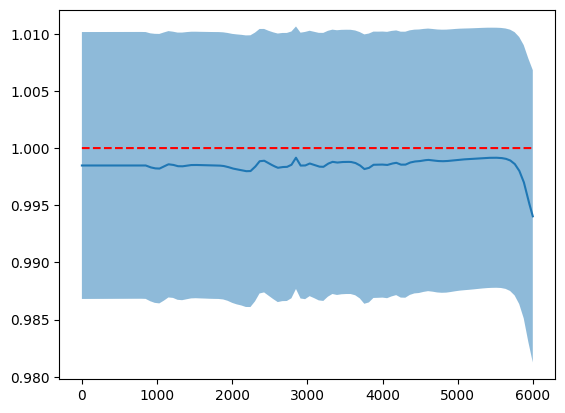

In [24]:
for u in unfold_results:
    #plt.plot(t, u['unfolded'] @ f_step)
    u_err = np.sqrt(u['stat_err']**2 + np.nan_to_num(u['sys_err'])**2)
    plt.fill_between(t, (u['unfolded']- u_err) @ f_step, (u['unfolded']+ u_err) @ f_step, alpha=0.5)
    plt.plot(t, u['unfolded'] @ f_step)
plt.plot(t, 1 + 0.*t, ls='--', c='r')
#plt.ylim((0.7,1.3))
plt.show()

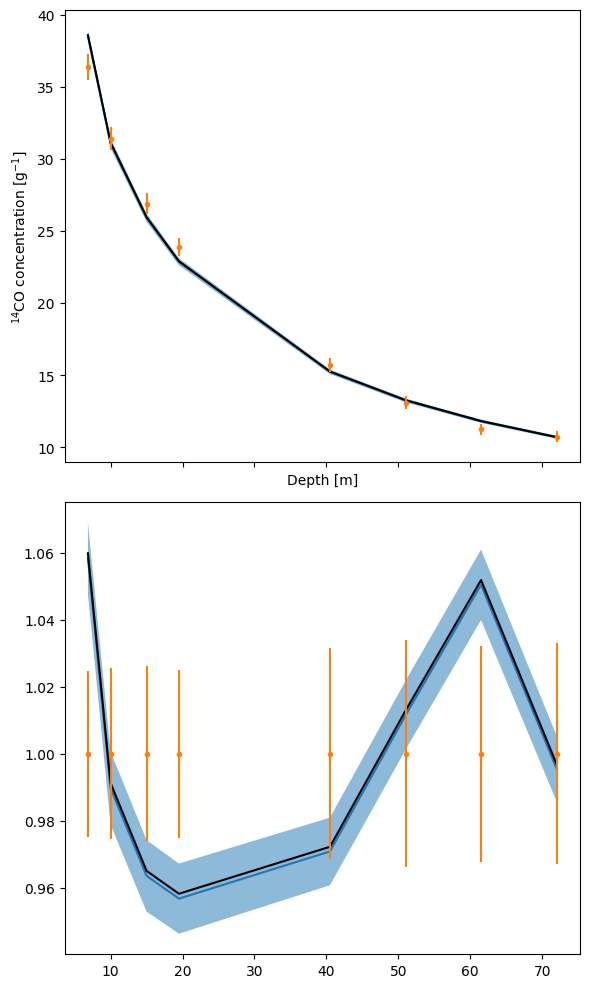

In [25]:
mod = C_n[i,0,0]*f_n + f @ C_init[i,j]

u = unfold_results[0]
u_err = np.sqrt(u['stat_err']**2 + np.nan_to_num(u['sys_err'])**2)

fig, (ax1,ax2) = plt.subplots(2,1, figsize=(6,10), tight_layout=True, sharex=True)

ax1.fill_between(z_samp, (u['unfolded']-u_err) @ CO_step[i,j] + mod, (u['unfolded']+u_err) @ CO_step[i,j] + mod, alpha=0.5)
ax1.plot(z_samp, u['unfolded'] @ CO_step[i,j] + mod)
ax1.plot(z_samp, C@f + C_n[i,0,0]*f_n, c='k', label='total prediction')
ax1.errorbar(z_samp, C_exp, yerr=C_err, fmt='.')

ax2.fill_between(z_samp, ((u['unfolded']-u_err) @ CO_step[i,j] + mod) / C_exp, ((u['unfolded']+u_err) @ CO_step[i,j] + mod)  / C_exp, alpha=0.5)
ax2.plot(z_samp, (u['unfolded'] @ CO_step[i,j] + mod) / C_exp)
ax2.plot(z_samp, (C@f + C_n[i,0,0]*f_n) / C_exp, c='k', label='total prediction')
ax2.errorbar(z_samp, C_exp / C_exp, yerr=C_err /C_exp, fmt='.')


ax1.set(xlabel='Depth [m]',
           #xscale='log',
           ylabel=r'$^{14}$CO concentration [g$^{-1}$]',
           #yscale='log',
      )
#ax1.legend()
#plt.title('Taylor Glacier Re-Analysis')
plt.show()

In [26]:
all_profiles = loadmat('matlab/MC_14CO_mod/all_profiles.mat')

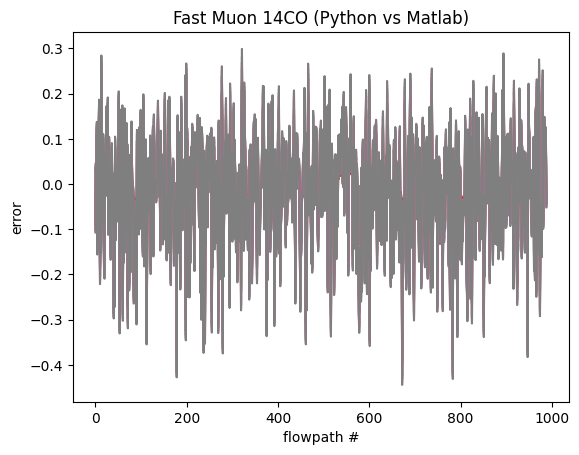

In [27]:
plt.plot((C_flow[:,13,0] / all_profiles['C_muf'])-1)
plt.xlabel('flowpath #')
plt.ylabel('error')
plt.title('Fast Muon 14CO (Python vs Matlab)')
plt.show()

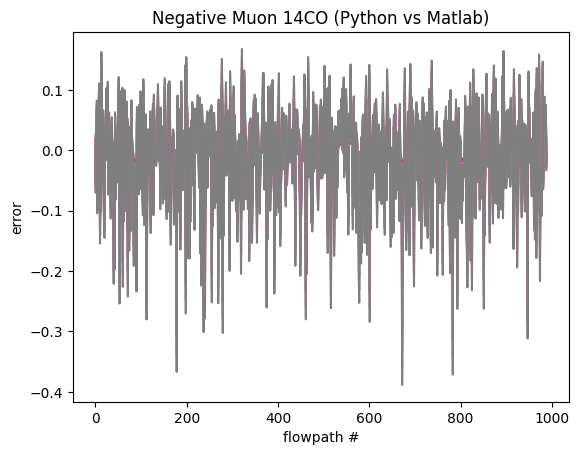

In [28]:
plt.plot((C_flow[:,13,1] / all_profiles['C_neg'])-1)
plt.xlabel('flowpath #')
plt.ylabel('error')
plt.title('Negative Muon 14CO (Python vs Matlab)')
plt.show()

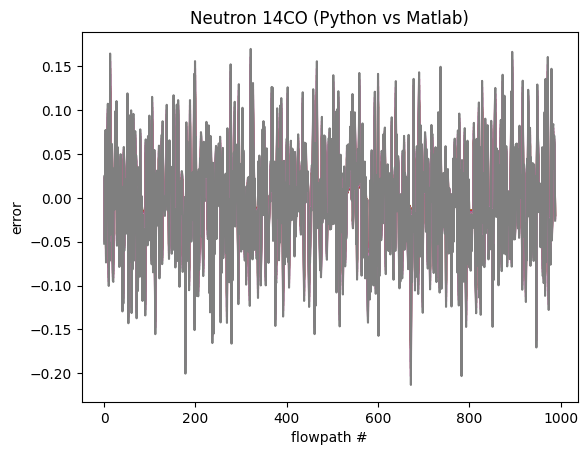

In [29]:
plt.plot((C_n[:,0,0]/all_profiles['C_n'])-1)
plt.xlabel('flowpath #')
plt.ylabel('error')
plt.title('Neutron 14CO (Python vs Matlab)')
plt.show()